In [ ]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolov8n.pt")  # lightweight and fast

In [ ]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)

Saving Fresh fruit arrangement on wood.png to Fresh fruit arrangement on wood.png


In [ ]:
results = model(img)

counts = {}

for r in results:
    boxes = r.boxes

    for box in boxes:
        cls = int(box.cls[0])
        label = model.names[cls]
        if label not in counts:
            counts[label] = 0
        counts[label] += 1
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        width = x2 - x1
        height = y2 - y1

        text = f"{label} W:{width}px H:{height}px"
        cv2.putText(img, text, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)


0: 448x640 1 banana, 5 apples, 2 oranges, 1 dining table, 340.1ms
Speed: 13.0ms preprocess, 340.1ms inference, 39.0ms postprocess per image at shape (1, 3, 448, 640)


In [ ]:
print("Object Counts:")
for k, v in counts.items():
    print(f"{k}: {v}")

Object Counts:
banana: 1
apple: 5
orange: 2
dining table: 1


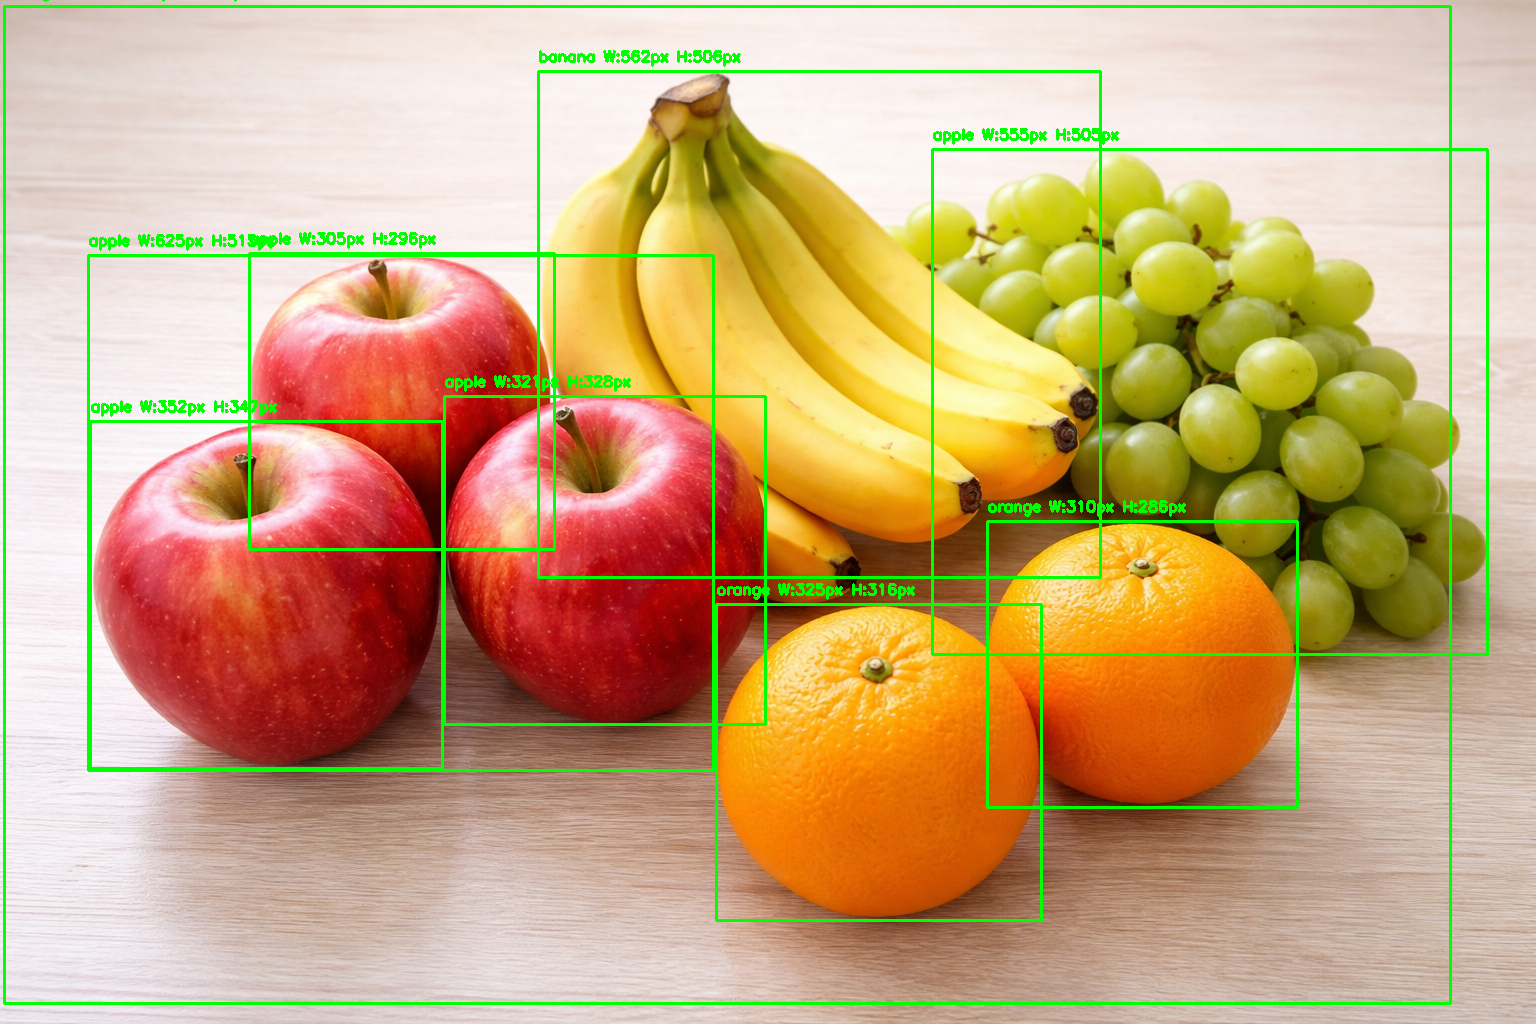

In [ ]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)